In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from numpy.typing import NDArray

from neural_network import NeuralNetwork
from dense_layer import DenseLayer
from activation_function import ReLU, SoftmaxCrossEntropy

# Carregamento dos dados
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

X = df
y = pd.Series(data.target)

np.random.seed(42)

In [2]:
def train_test_split(X: NDArray[np.float32], y: NDArray[np.float32], test_size: float = 0.2, shuffle: bool = True):
    '''
    Realiza a divisão de um dataset em parcela de treino e teste seguindo a divisão padrão de 80/20 (Respectivamente).
    Entrada:
        - X: Matriz de features (num_samples, num_features)
        - y: Vetor de rótulos (num_samples,)
        - test_size: Proporção do dataset a ser alocada para teste (default: 0.2)
    Saída:
        - X_train: Matriz de features para treino
        - X_test: Matriz de features para teste
        - y_train: Vetor de rótulos para treino
        - y_test: Vetor de rótulos para teste
    '''
    num_samples = len(y)
    
    if shuffle:
        ixs = np.random.permutation(num_samples)
        X = X.iloc[ixs]
        y = y.iloc[ixs]

    test_len = np.floor(test_size * num_samples).astype(np.int32)

    X_test = X[:test_len]
    X_train = X[test_len:]

    y_test = y[:test_len]
    y_train = y[test_len:]

    assert len(X_test) + len(X_train) == num_samples, "Dados perdidos no train_test_split (X)"
    assert len(y_test) + len(y_train) == num_samples, "Dados perdidos no train_test_split (y)"
    
    return X_train, X_test, y_train, y_test 

def to_one_hot(y, num_classes=2):
    """
    Converte rótulos (batch,) em one-hot (num_classes, batch).
    """
    y = np.asarray(y, dtype=np.int32).flatten()
    m = y.shape[0]
    Y = np.zeros((num_classes, m), dtype=np.float32)
    Y[y, np.arange(m)] = 1.0
    return Y

def get_mini_batch(X_train: NDArray[np.float32], y_train: NDArray[np.float32], batch_size: int = 32):
    """
    Recebe o dataset de treinamento, realiza shuffle aleatorio e divide em batches
    de tamanho padrão 32.
    Entrada:
        - X_train: Matriz de features para treino (num_samples, num_features)
        - y_train: Vetor de rótulos para treino (num_samples,)
    Saída:
        - mini_batches: Lista de tuplas (X_batch, y_batch) onde cada tupla contém um batch de dados
    """
    y_len = len(y_train)
    
    # Realiza permutação dos dados
    ixs = np.random.permutation(y_len)
    X = X_train.iloc[ixs]
    y = y_train.iloc[ixs]

    batches = []
    for i in range(0, len(X), batch_size):
        X_batch = X[i : i + batch_size].to_numpy().T  # (n_features, batch_size)
        y_batch = to_one_hot(y[i : i + batch_size])   # (num_classes, batch_size)

        batches.append((X_batch, y_batch))

    return batches

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """
    Plota a evolução da Loss e da Acurácia ao longo das épocas de treinamento.
    Entrada:
        - train_losses: Lista com os valores de loss de treino por época
        - val_losses: Lista com os valores de loss de validação por época
        - train_accs: Lista com os valores de acurácia de treino por época
        - val_accs: Lista com os valores de acurácia de validação por época
    """
    epochs = range(1, len(train_losses) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de Evolução da Loss
    axes[0].plot(epochs, train_losses, label='Treino', color='#4C72B0', marker='o', markersize=4)
    axes[0].plot(epochs, val_losses, label='Validação', color='#C44E52', marker='o', markersize=4)
    axes[0].set_title('Evolução da Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Gráfico de Evolução da Acurácia
    axes[1].plot(epochs, train_accs, label='Treino', color='#55A868', marker='o', markersize=4)
    axes[1].plot(epochs, val_accs, label='Validação', color='#E1812C', marker='o', markersize=4)
    axes[1].set_title('Evolução da Acurácia')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].set_ylim(0, 1)

    best_epoch = np.argmin(val_losses) + 1
    
    # Adicionando a marcação de Early Stopping no gráfico de Loss
    axes[0].axvline(x=best_epoch, color='black', linestyle=':', label=f'Early stop (Época {best_epoch})')
    axes[0].legend()
    
    # Adicionando a marcação de Early Stopping no gráfico de Acurácia
    axes[1].axvline(x=best_epoch, color='black', linestyle=':', label=f'Early stop (Época {best_epoch})')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def normalize(X_train: NDArray[np.float32], X_test: NDArray[np.float32]):
    media = X_train.mean(axis=0)
    desvio = X_train.std(axis=0)
    
    X_train = (X_train - media) / desvio
    X_test = (X_test - media) / desvio
    
    return X_train, X_test



In [3]:
# Mapping das features
feature_mapping = {0: "malignant", 1: "benign"}

# Número de epocas de treinamento
num_epochs = 100

# Taxa de aprendizado
lr = 0.005

##### Loop de Treinamento



                Epoch 10/100, 
                Test Loss: 0.6724, 
                Test Acc: 0.6322, 
                Val Loss: 0.6785,
                Val Acc: 0.6000
                

                Epoch 20/100, 
                Test Loss: 0.6606, 
                Test Acc: 0.6322, 
                Val Loss: 0.6726,
                Val Acc: 0.6000
                

                Epoch 30/100, 
                Test Loss: 0.6573, 
                Test Acc: 0.6322, 
                Val Loss: 0.6720,
                Val Acc: 0.6000
                

                Epoch 40/100, 
                Test Loss: 0.6539, 
                Test Acc: 0.6322, 
                Val Loss: 0.6701,
                Val Acc: 0.6000
                

                Epoch 50/100, 
                Test Loss: 0.6443, 
                Test Acc: 0.6322, 
                Val Loss: 0.6616,
                Val Acc: 0.6000
                

                Epoch 60/100, 
                Test Loss: 0.6097, 
  

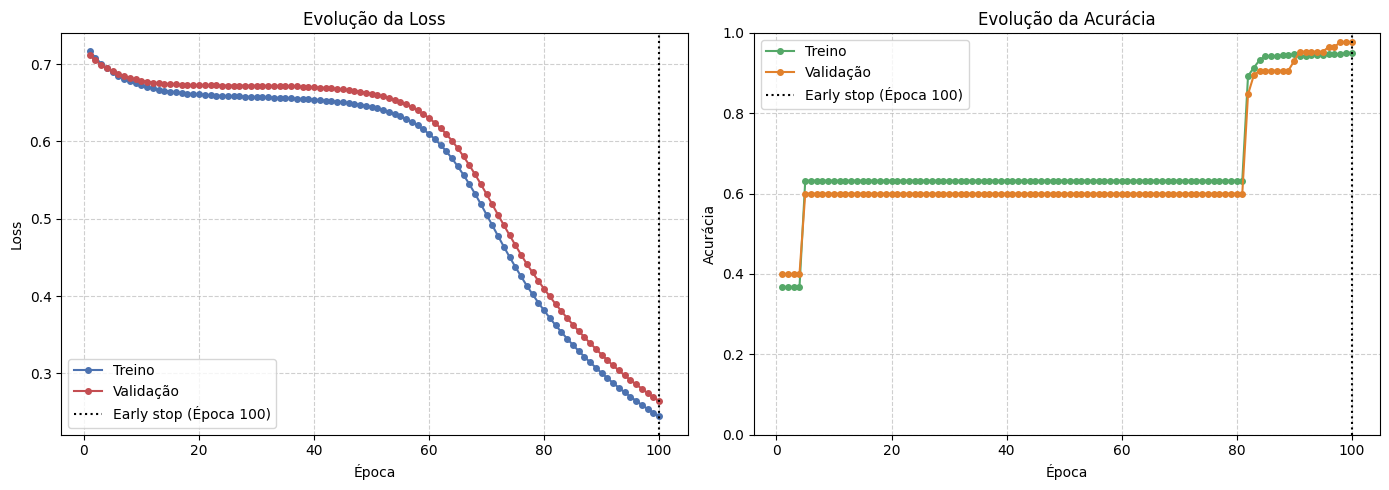

In [9]:
# Divisão treino/validação
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size = 0.15)
X_train, X_val = normalize(X_train, X_val)
n_features = X_train.shape[1]

layers = [ # Hidden Layers
    DenseLayer(8, n_features, ReLU()),
    DenseLayer(8, 8, ReLU()),
    DenseLayer(4, 8, ReLU()),
    DenseLayer(4, 4, ReLU()),
    DenseLayer(2, 4, ReLU()),
    DenseLayer(2, 2),  # Camada de saída [p_maligno, p_benigno]. Sem ativação pq é passada pra softmax em NeuralNetwork
]

layers2 = [ # Hidden Layers
    DenseLayer(8, n_features, ReLU()),
    DenseLayer(2, 8, ReLU()),
    DenseLayer(2, 2),  # Camada de saída [p_maligno, p_benigno]. Sem ativação pq é passada pra softmax em NeuralNetwork
]

model = NeuralNetwork(layers2, SoftmaxCrossEntropy())

# Formato esperado pela rede: (n_features, n_samples) e (num_classes, n_samples)
X_train_np = X_train.to_numpy().T
X_val_np = X_val.to_numpy().T
y_train_oh = to_one_hot(y_train)
y_val_oh = to_one_hot(y_val)

# Armazena histórico de treinamento
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

lr = 0.005

# Loop de treinamento
for e in range(num_epochs):
    # Gera mini-batches para a época atual
    mini_batches = get_mini_batch(X_train, y_train, batch_size=16)

    # Treina o modelo em cada mini-batch
    for X_batch, y_batch in mini_batches:
        model.fit(X_batch, y_batch, learning_rate=lr)

    # Calcula métricas de treino e validação
    train_loss = model.loss_activation.forward(model.predict(X_train_np), y_train_oh)
    train_preds = np.argmax(model.loss_activation.A, axis=0)
    train_acc   = np.mean(train_preds == np.argmax(y_train_oh, axis=0))
    val_loss = model.loss_activation.forward(model.predict(X_val_np), y_val_oh)
    val_preds = np.argmax(model.loss_activation.A, axis=0)
    val_acc   = np.mean(val_preds == np.argmax(y_val_oh, axis=0))

    # Armazena métricas da época atual
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    if (e + 1) % 10 == 0:
        print(f"""
                Epoch {e + 1}/{num_epochs}, 
                Test Loss: {train_loss:.4f}, 
                Test Acc: {train_acc:.4f}, 
                Val Loss: {val_loss:.4f},
                Val Acc: {val_acc:.4f}
                """)
 
plot_training_history(train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist)
